---
# Разведочный анализ данных (EDA)
---

**Цель:** исследовать структуру данных, выявить информативные признаки и паттерны, обнаружить временной дрейф train → test, сформулировать гипотезы для feature engineering.

**Данные:** `train_apps.csv` (145 241 заявка, 2024-02-01 - 2025-06-05), `test_apps.csv` (36 311 заявок, 2025-06-05 - 2025-12-01).

## Структура анализа

1. Загрузка данных и инженерия признаков для EDA
2. Пропуски как предиктор: связь `is_missing` с `target_value`
3. Временной дрейф: PSI и KDE train vs test
4. Визуализация дрейфующих признаков
5. Корреляция числовых признаков с таргетом (Spearman) и зависимость по квантильным бинам
6. Взаимодействия пар ключевых признаков
7. Анализ категориальных признаков (`db_group_last`, `fl_adminarea`)
8. Временная динамика acceptance rate по продуктовым сегментам

### 1. Загрузка данных и инженерия признаков для EDA

Загружаем train и test, применяем функцию `add_eda_features`, которая добавляет вспомогательные признаки для анализа:

- **Дата:** `decision_day_num` (дней от минимальной даты), `decision_month`, `decision_dayofweek`, `is_weekend`, `is_sunday`.
- **Rate spread:** `rate_spread = offered_rate − cb_rate` - разница между предложенной ставкой и ключевой ставкой ЦБ. Отражает «агрессивность» офера.
- **Loan-to-limit ratios:** `loan_to_limit_min/max` - отношение суммы кредита к лимитам овердрафта. Сигнализирует о соответствии условий клиентскому профилю.
- **Completeness:** `missing_count`, `missing_share` - полнота профиля клиента.

Все трансформации применяются **одинаково** к train и test, без использования статистик test при вычислении чего-либо по train.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.6,
})

train_eda = pd.read_csv(r"data\train_apps.csv")
test_eda = pd.read_csv(r"data\test_apps.csv")

TARGET_COL = "target_value"
ID_COL = "front_id"
DATE_COL = "decision_day"

def safe_divide(numerator, denominator):
    return numerator / (np.abs(denominator) + 1e-6)

def add_eda_features(data):
    result = data.copy()
    result[DATE_COL] = pd.to_datetime(result[DATE_COL])

    result["decision_day_num"] = (result[DATE_COL] - result[DATE_COL].min()).dt.days
    result["decision_month"] = result[DATE_COL].dt.to_period("M").astype(str)
    result["decision_weekday"] = result[DATE_COL].dt.day_name()
    result["decision_dayofweek"] = result[DATE_COL].dt.weekday
    result["is_weekend"] = result["decision_dayofweek"].isin([5, 6]).astype(int)
    result["is_sunday"] = (result["decision_dayofweek"] == 6).astype(int)

    result["rate_spread"] = result["offered_rate"] - result["cb_rate"]
    result["abs_rate_spread"] = result["rate_spread"].abs()
    result["rate_ratio"] = safe_divide(result["offered_rate"], result["cb_rate"])

    result["overdraft_range"] = result["overdraft_limit_max"] - result["overdraft_limit_min"]
    result["overdraft_mean"] = (result["overdraft_limit_max"] + result["overdraft_limit_min"]) / 2
    result["loan_to_limit_min"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_min"])
    result["loan_to_limit_max"] = safe_divide(result["loan_amount_last"], result["overdraft_limit_max"])
    result["loan_to_limit_mean"] = safe_divide(result["loan_amount_last"], result["overdraft_mean"])

    result["sum_deb_ul_ratio_30_90"] = safe_divide(result["sum_deb_ul_30"], result["sum_deb_ul_90"])
    result["cnt_deb_ul_ip_ratio_30_90"] = safe_divide(result["cnt_deb_ul_ip_30"], result["cnt_deb_ul_ip_90"])
    result["sum_deb_ul_diff_90_30"] = result["sum_deb_ul_90"] - result["sum_deb_ul_30"]
    result["cnt_deb_ul_ip_diff_90_30"] = result["cnt_deb_ul_ip_90"] - result["cnt_deb_ul_ip_30"]

    result["digital_activity_sum"] = (
        result["corp_credit_products"]
        + result["corp_list"]
        + result["count_all_corp_dashboard_events"]
        + result["p75_time_spent_minutes"]
    )

    feature_cols = [col for col in result.columns if col not in [TARGET_COL, ID_COL, DATE_COL]]
    result["missing_count"] = result[feature_cols].isna().sum(axis=1)
    result["missing_share"] = result["missing_count"] / len(feature_cols)

    return result

train_eda = add_eda_features(train_eda)
test_eda = add_eda_features(test_eda)

train_eda.shape, test_eda.shape

((145241, 49), (36311, 48))

### 2. Пропуски как предиктор

20 из 25 сырых признаков содержат пропуски. Механизм пропусков - **MNAR** (Missing Not At Random): отсутствие значения несёт информацию само по себе. Для каждого признака $j$ с пропусками вычисляем:

$$
\Delta_j = \bar{y}^{\text{miss}}_j - \bar{y}^{\text{present}}_j,
$$

где $\bar{y}^{\text{miss}}_j$ - среднее значение таргета среди строк с пропуском, $\bar{y}^{\text{present}}_j$ - среди строк с известным значением.

Большое $|\Delta_j|$ указывает, что факт пропуска напрямую предсказывает таргет. Такие признаки должны быть закодированы **бинарным индикатором** `{col}_isna`, а не просто заполнены медианой.

,feature,train_missing_pct,test_missing_pct,target_rate_missing,target_rate_present,target_rate_diff
11,overdraft_app_term_max_360,96.206994,92.010685,0.051119,0.309131,-0.258011
8,loan_rev_max_start_non_fin,91.320633,85.717827,0.047318,0.203871,-0.156553
9,loan_rev_min_start_fin,85.861430,74.126298,0.043871,0.164354,-0.120482
20,sum_deb_ul_ratio_30_90,42.395054,28.715816,0.021015,0.090264,-0.069249
22,sum_deb_ul_diff_90_30,42.395054,28.715816,0.021015,0.090264,-0.069249
2,sum_deb_ul_30,42.311055,28.655228,0.020959,0.090204,-0.069245
1,sum_deb_ul_90,37.256009,23.695299,0.019700,0.085373,-0.065672
0,corp_credit_products,35.243492,20.935805,0.022017,0.082071,-0.060054
16,p75_time_spent_minutes,35.243492,20.935805,0.022017,0.082071,-0.060054
15,count_all_corp_dashboard_events,35.243492,20.935805,0.022017,0.082071,-0.060054


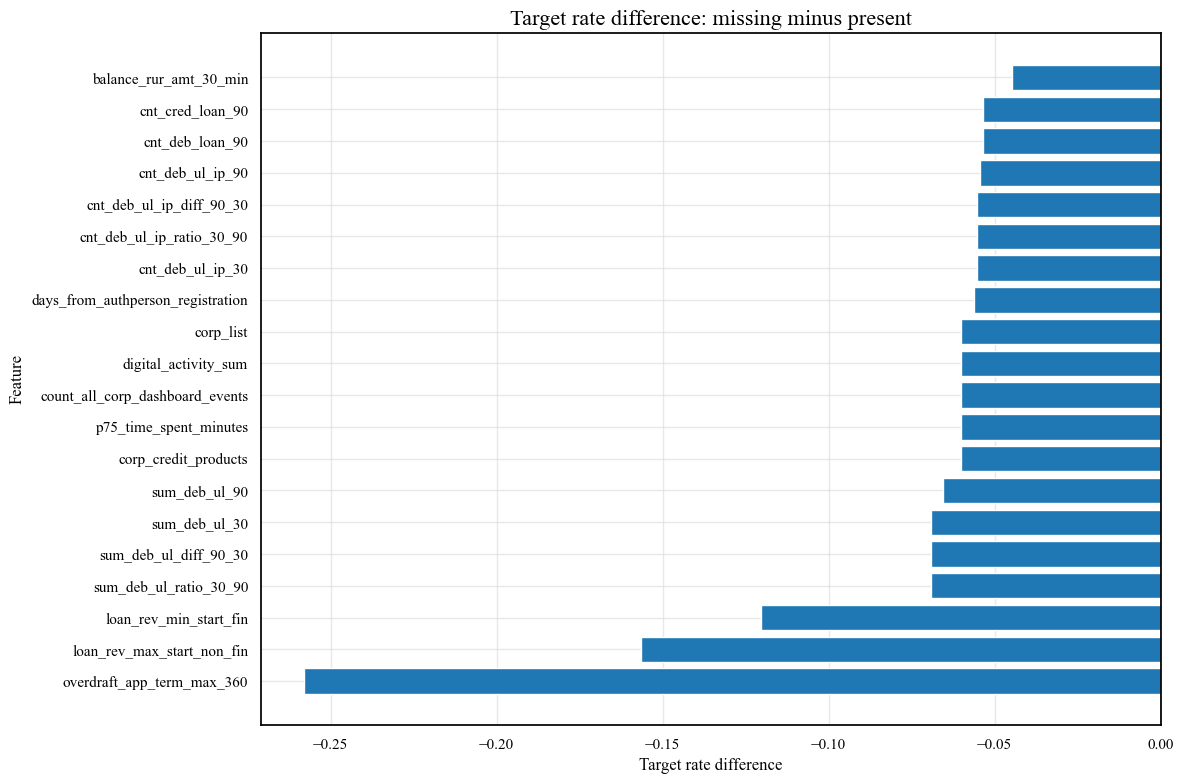

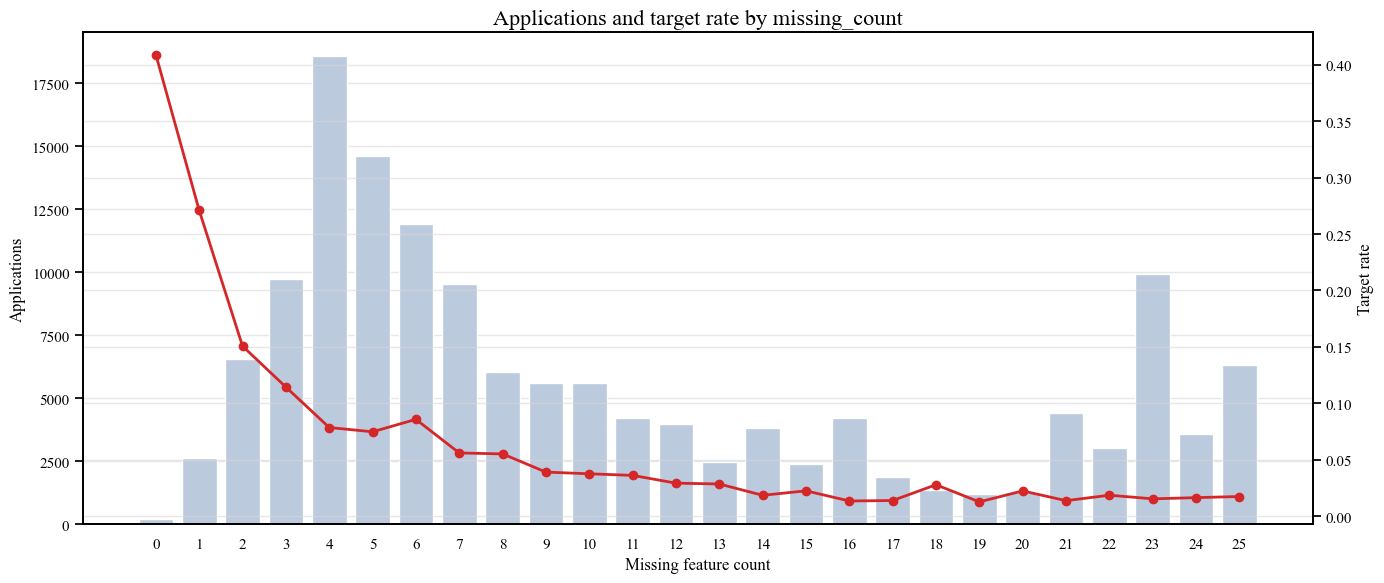

In [2]:
feature_cols = [col for col in train_eda.columns if col not in [TARGET_COL, ID_COL, DATE_COL]]

missing_rows = []

for col in feature_cols:
    train_missing = train_eda[col].isna()
    test_missing = test_eda[col].isna() if col in test_eda.columns else pd.Series(False, index=test_eda.index)

    if train_missing.nunique() < 2:
        continue

    target_missing = train_eda.loc[train_missing, TARGET_COL].mean()
    target_present = train_eda.loc[~train_missing, TARGET_COL].mean()

    missing_rows.append({
        "feature": col,
        "train_missing_pct": train_missing.mean() * 100,
        "test_missing_pct": test_missing.mean() * 100,
        "target_rate_missing": target_missing,
        "target_rate_present": target_present,
        "target_rate_diff": target_missing - target_present,
    })

missing_impact = (
    pd.DataFrame(missing_rows)
    .sort_values("target_rate_diff", key=lambda x: x.abs(), ascending=False)
)

display(missing_impact.head(25))

plot_df = missing_impact.head(20).sort_values("target_rate_diff")

plt.figure(figsize=(12, 8))
colors = ["#D62728" if value > 0 else "#1F77B4" for value in plot_df["target_rate_diff"]]
plt.barh(plot_df["feature"], plot_df["target_rate_diff"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Target rate difference: missing minus present", fontsize=16)
plt.xlabel("Target rate difference")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

missing_count_stats = (
    train_eda
    .groupby("missing_count", observed=True)
    .agg(
        applications=(ID_COL, "count"),
        target_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=missing_count_stats, x="missing_count", y="applications", color="#B7C9E2", ax=ax)
ax.set_title("Applications and target rate by missing_count", fontsize=16)
ax.set_xlabel("Missing feature count")
ax.set_ylabel("Applications")

ax2 = ax.twinx()
ax2.plot(
    missing_count_stats["missing_count"],
    missing_count_stats["target_rate"],
    color="#D62728",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Target rate")

plt.tight_layout()
plt.show()

### 3. Временной дрейф признаков: PSI

Между train и test существует разрыв около 6 месяцев. Для каждого числового признака вычисляется **Population Stability Index (PSI)** - мера сдвига распределения:

$$
\text{PSI} = \sum_{k=1}^{K} \left(p^{\text{test}}_k - p^{\text{train}}_k\right) \cdot \ln\!\frac{p^{\text{test}}_k}{p^{\text{train}}_k},
$$

где $p^{\text{train}}_k$ и $p^{\text{test}}_k$ - доли наблюдений в $k$-м квантильном бине (границы бинов фиксируются по train). Значение PSI > 0.25 свидетельствует о значительном дрейфе. Дополнительно вычисляется статистика **KS-теста** ($D = \sup_x |F_{\text{train}}(x) - F_{\text{test}}(x)|$) для подтверждения.

,feature,psi,ks_stat,train_mean,test_mean,mean_diff,train_missing_pct,test_missing_pct
23,decision_day_num,4.840447,0.435518,179.854745,97.484591,-82.370153,0.000000,0.000000
27,rate_spread,2.441541,0.268287,0.215615,0.637720,0.422105,0.000000,0.000000
3,offered_rate,2.102288,0.257113,0.451652,0.954576,0.502924,0.000000,0.000000
29,rate_ratio,1.662104,0.249332,0.775564,231922.064089,231921.288525,0.000000,0.000000
4,cb_rate,1.085103,0.564517,0.236037,0.316856,0.080819,0.000000,0.000000
28,abs_rate_spread,0.829387,0.275742,4.526412,21.667145,17.140733,0.000000,0.000000
2,overdraft_limit_max,0.404556,0.230998,-0.152180,1.125704,1.277884,0.000000,0.000000
31,overdraft_mean,0.355066,0.221111,-0.115825,1.207708,1.323533,0.000000,0.000000
1,overdraft_limit_min,0.303393,0.207871,-0.079469,1.289713,1.369181,0.000000,0.000000
30,overdraft_range,0.287015,0.170210,-0.072712,-0.164009,-0.091297,0.000000,0.000000


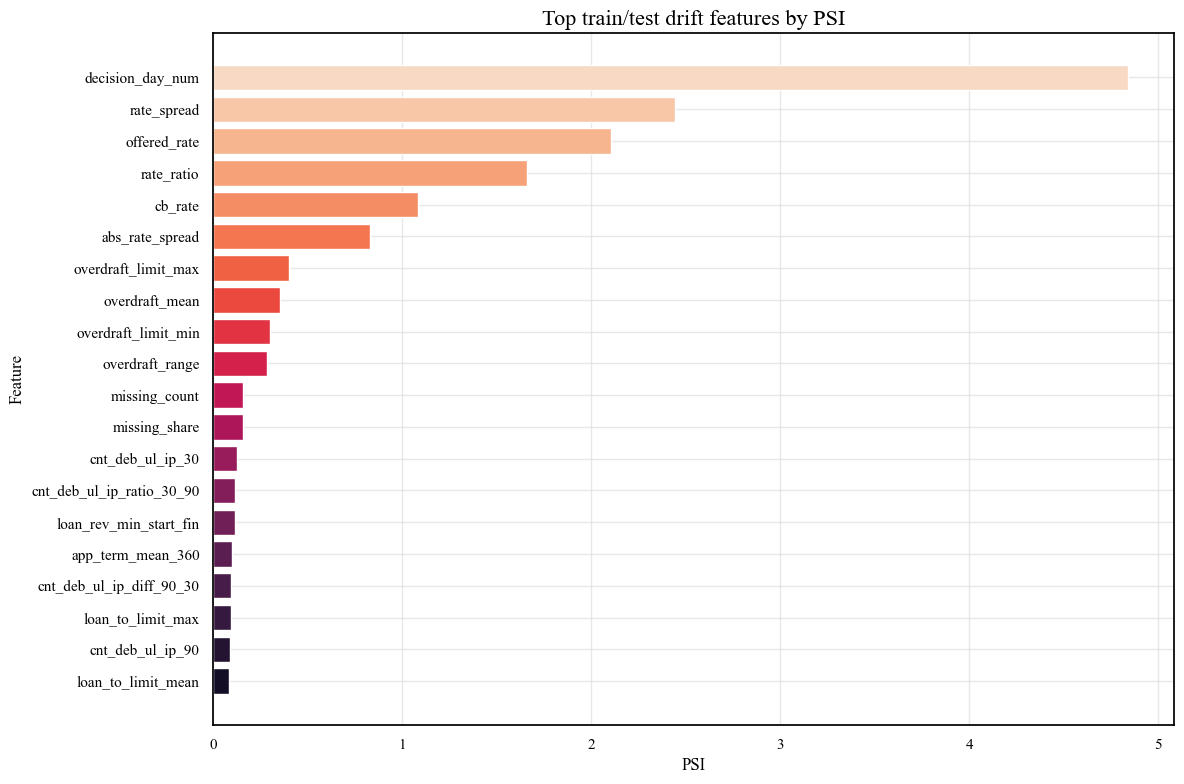

In [3]:
def calculate_psi(train_values, test_values, bins=10):
    train_values = pd.Series(train_values).replace([np.inf, -np.inf], np.nan).dropna()
    test_values = pd.Series(test_values).replace([np.inf, -np.inf], np.nan).dropna()

    if train_values.nunique() <= 1 or test_values.nunique() <= 1:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    edges = train_values.quantile(quantiles).drop_duplicates().values

    if len(edges) < 3:
        return np.nan

    train_bins = pd.cut(train_values, bins=edges, include_lowest=True, duplicates="drop")
    test_bins = pd.cut(test_values, bins=edges, include_lowest=True, duplicates="drop")

    train_dist = train_bins.value_counts(normalize=True, sort=False)
    test_dist = test_bins.value_counts(normalize=True, sort=False)

    aligned = pd.concat([train_dist, test_dist], axis=1).fillna(1e-6)
    aligned.columns = ["train", "test"]

    aligned["train"] = aligned["train"].clip(1e-6)
    aligned["test"] = aligned["test"].clip(1e-6)

    psi = ((aligned["test"] - aligned["train"]) * np.log(aligned["test"] / aligned["train"])).sum()
    return psi

numeric_cols = [
    col for col in train_eda.select_dtypes(include="number").columns
    if col not in [TARGET_COL, ID_COL]
    and col in test_eda.columns
]

drift_rows = []

for col in numeric_cols:
    train_values = train_eda[col]
    test_values = test_eda[col]

    train_clean = train_values.replace([np.inf, -np.inf], np.nan).dropna()
    test_clean = test_values.replace([np.inf, -np.inf], np.nan).dropna()

    if train_clean.nunique() <= 1 or test_clean.nunique() <= 1:
        continue

    ks_stat, ks_pvalue = ks_2samp(train_clean, test_clean)

    drift_rows.append({
        "feature": col,
        "psi": calculate_psi(train_values, test_values),
        "ks_stat": ks_stat,
        "train_mean": train_clean.mean(),
        "test_mean": test_clean.mean(),
        "mean_diff": test_clean.mean() - train_clean.mean(),
        "train_missing_pct": train_values.isna().mean() * 100,
        "test_missing_pct": test_values.isna().mean() * 100,
    })

drift_df = pd.DataFrame(drift_rows).sort_values("psi", ascending=False)
display(drift_df.head(25))

plot_df = drift_df.head(20).sort_values("psi")

plt.figure(figsize=(12, 8))
plt.barh(plot_df["feature"], plot_df["psi"], color=sns.color_palette("rocket", len(plot_df)))
plt.title("Top train/test drift features by PSI", fontsize=16)
plt.xlabel("PSI")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 4. Визуализация распределений дрейфующих признаков

Для признаков с наибольшим PSI строим **KDE-графики** плотности распределения отдельно для train и test. Это позволяет понять характер дрейфа:

- **сдвиг** среднего значения (макро-условия изменились);
- **изменение дисперсии** (в test больше/меньше вариабельности);
- **появление новых мод** (новые сегменты клиентов или продуктов).

Признаки с ярко выраженным дрейфом (особенно ratio-фичи на базе `cb_rate`) исключаются из финального набора.

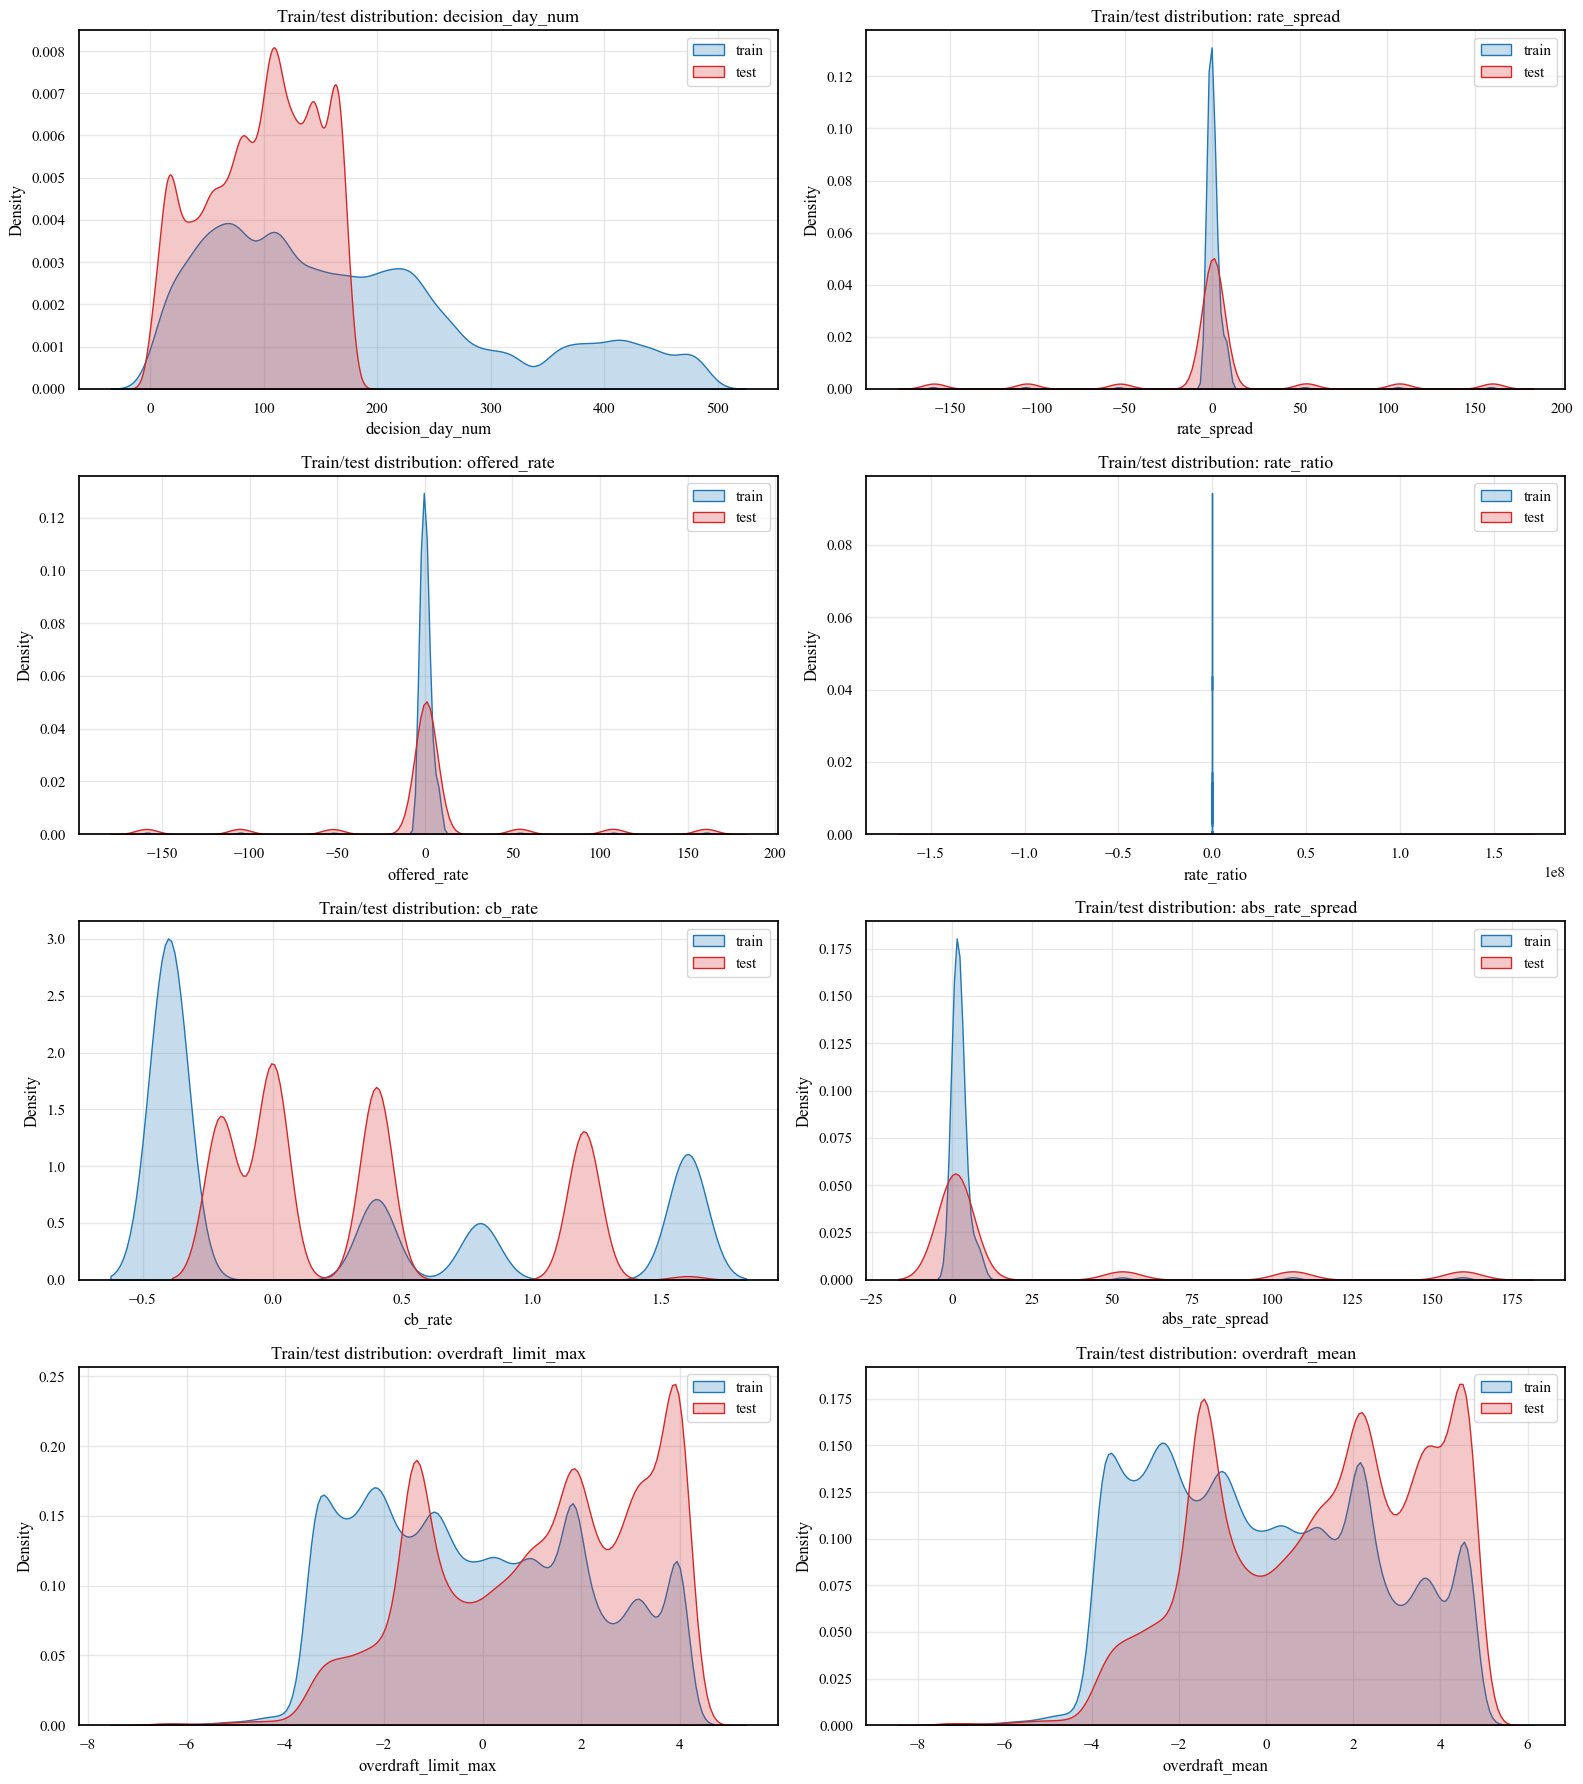

In [4]:
top_drift_features = drift_df.head(8)["feature"].tolist()

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, col in zip(axes, top_drift_features):
    sns.kdeplot(train_eda[col], label="train", ax=ax, color="#1F77B4", fill=True, alpha=0.25)
    sns.kdeplot(test_eda[col], label="test", ax=ax, color="#D62728", fill=True, alpha=0.25)
    ax.set_title(f"Train/test distribution: {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

### 5. Корреляция числовых признаков с таргетом

Для ранжирования числовых признаков по информативности используется **ранговая корреляция Спирмена** - она устойчива к выбросам и не предполагает линейной связи:

$$
\rho_s(X_j, y) = 1 - \frac{6 \sum_i (R_{X_{ij}} - R_{y_i})^2}{n(n^2 - 1)},
$$

где $R_{X_{ij}}$ и $R_{y_i}$ - ранги значений признака и таргета.

Дополнительно для топ-16 признаков строим **профиль acceptance rate** по квантильным бинам (`pd.qcut`): среднее значение таргета в каждом бине показывает форму монотонной или нелинейной зависимости.

,spearman_corr_with_target
loan_rev_max_start_non_fin,0.284811
missing_share,-0.170208
missing_count,-0.170208
cnt_cred_loan_90,0.143118
cnt_deb_ul_ip_90,0.136009
cnt_deb_ul_ip_diff_90_30,0.133173
cnt_deb_ul_ip_30,0.129848
app_term_mean_360,-0.128083
overdraft_app_term_max_360,-0.124382
sum_deb_ul_90,0.122818


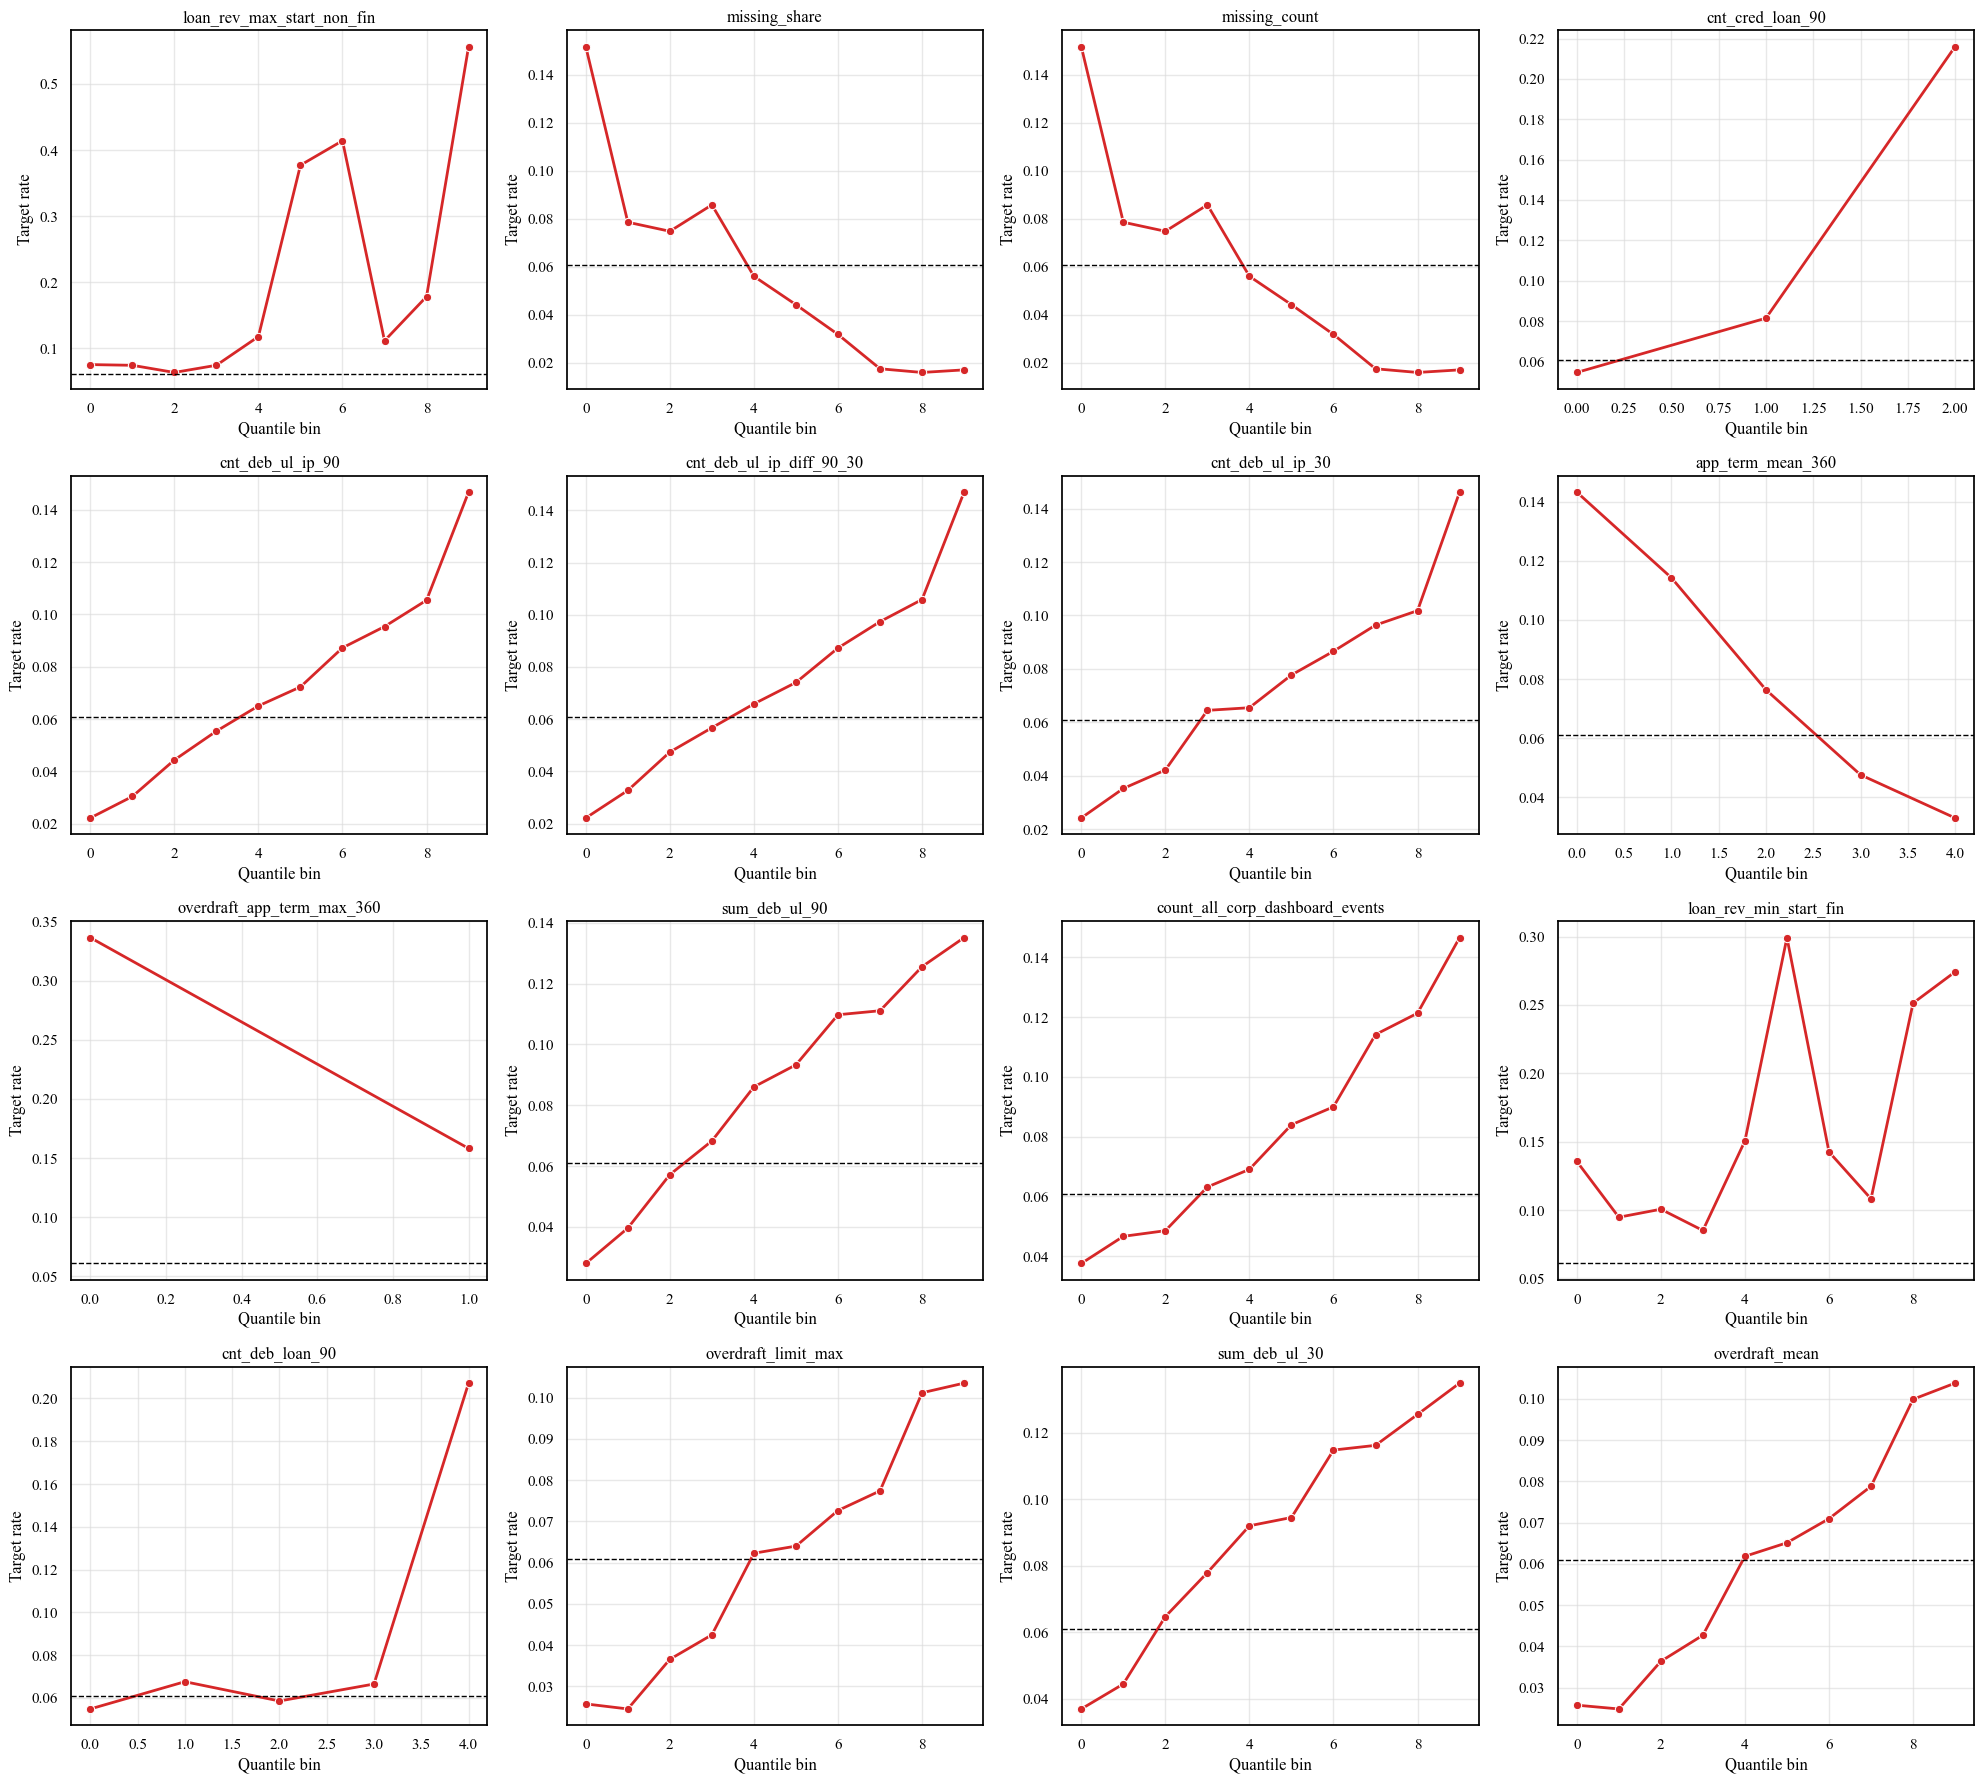

In [5]:
numeric_target_cols = [
    col for col in train_eda.select_dtypes(include="number").columns
    if col not in [TARGET_COL, ID_COL]
]

target_corr = (
    train_eda[numeric_target_cols + [TARGET_COL]]
    .corr(method="spearman")[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top_target_features = target_corr.head(16).index.tolist()
display(target_corr.head(25).to_frame("spearman_corr_with_target"))

def make_quantile_table(data, feature, bins=10):
    tmp = data[[feature, TARGET_COL]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if tmp[feature].nunique() < 3:
        return None

    tmp["bin"] = pd.qcut(tmp[feature], q=bins, duplicates="drop")
    result = (
        tmp
        .groupby("bin", observed=True)
        .agg(
            feature_mean=(feature, "mean"),
            applications=(TARGET_COL, "count"),
            target_rate=(TARGET_COL, "mean"),
        )
        .reset_index()
    )
    result["bin_num"] = np.arange(len(result))
    return result

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

global_target_rate = train_eda[TARGET_COL].mean()

for ax, feature in zip(axes, top_target_features):
    bin_table = make_quantile_table(train_eda, feature, bins=10)

    if bin_table is None:
        ax.axis("off")
        continue

    sns.lineplot(
        data=bin_table,
        x="bin_num",
        y="target_rate",
        marker="o",
        color="#D62728",
        linewidth=2,
        ax=ax,
    )
    ax.axhline(global_target_rate, color="black", linestyle="--", linewidth=1)
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel("Quantile bin")
    ax.set_ylabel("Target rate")

plt.tight_layout()
plt.show()

### 6. Взаимодействия пар признаков

Отдельные признаки могут иметь низкую маргинальную корреляцию с таргетом, но сильное **совместное влияние**. Тепловые карты acceptance rate на сетке квантильных бинов двух признаков позволяют выявить нелинейные взаимодействия.

Например, клиент с высоким `loan_amount_last` и низким `overdraft_limit_max` (loan > limit) ведёт себя иначе, чем при обратном соотношении - это бизнес-сигнал о «напряжённости» условий офера.

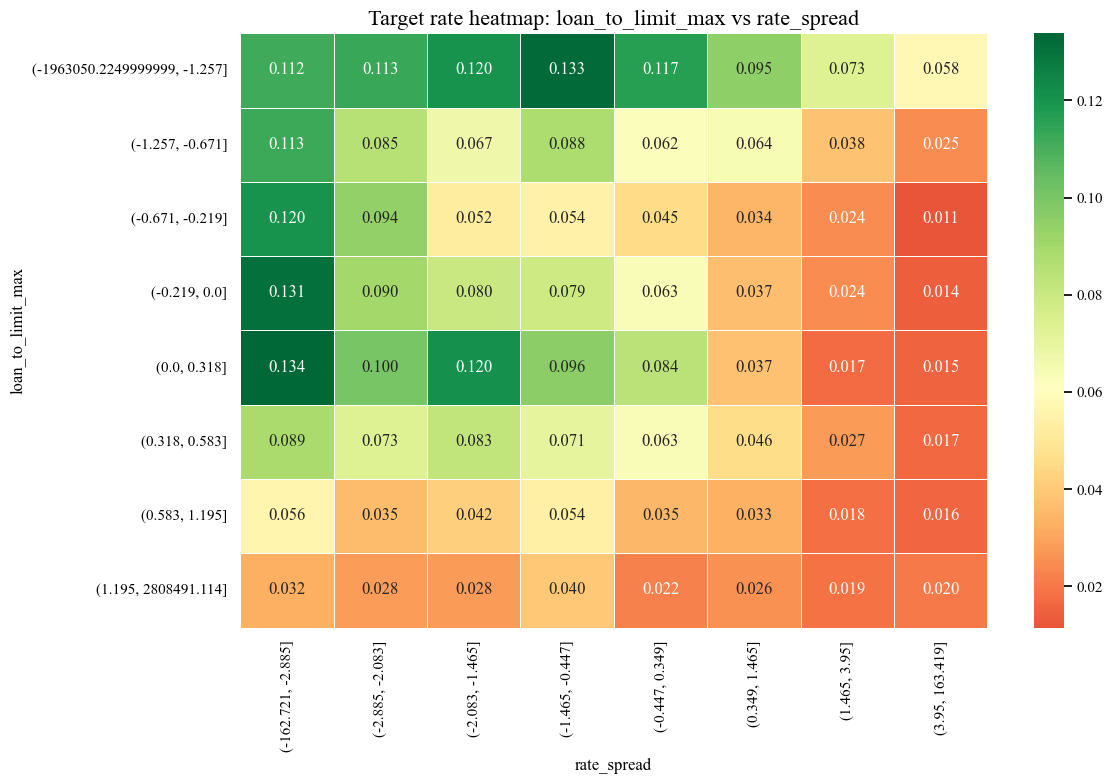

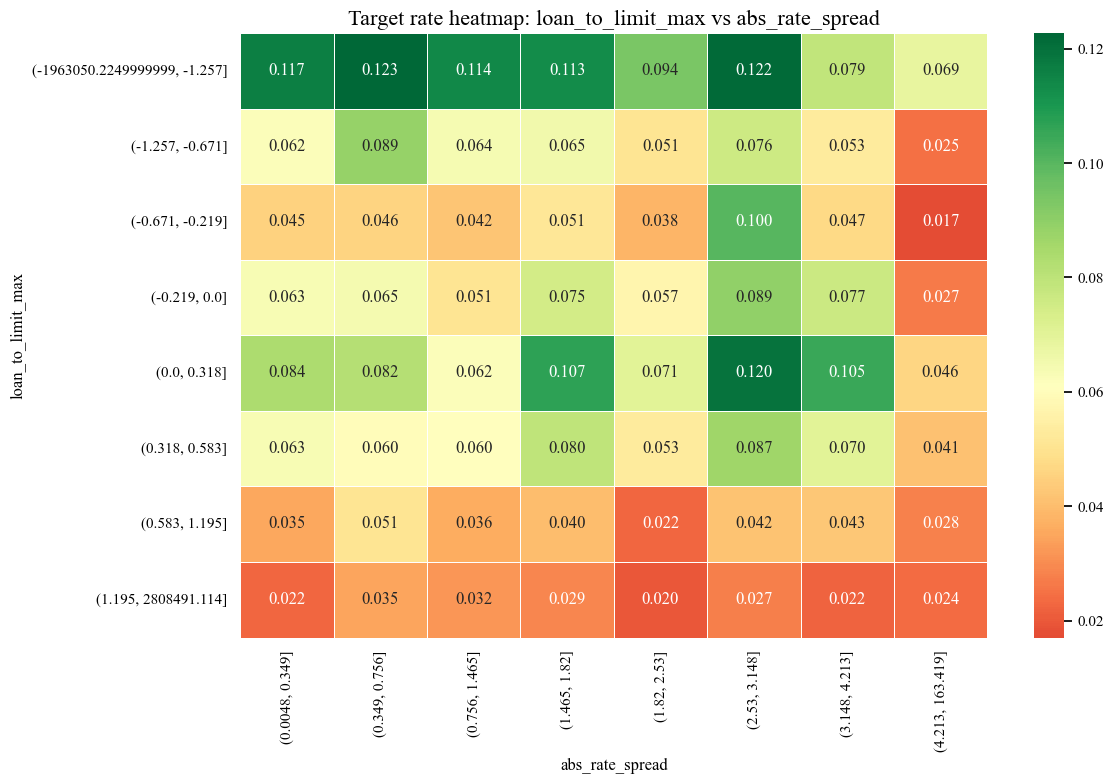

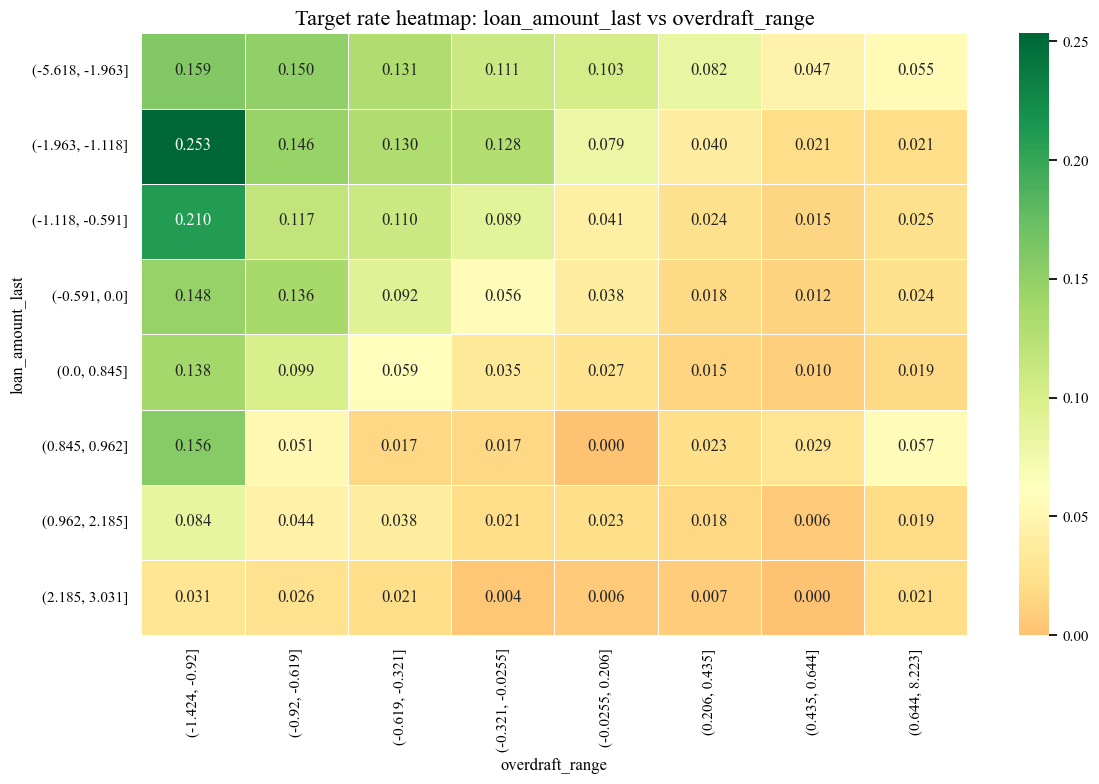

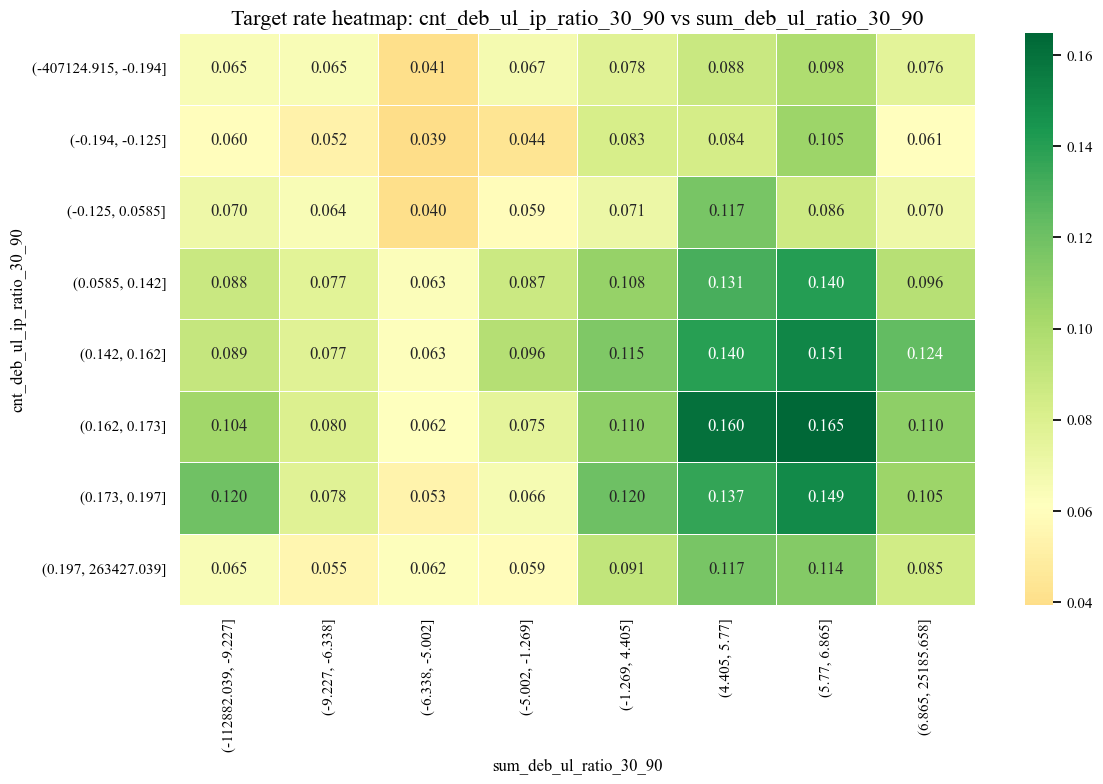

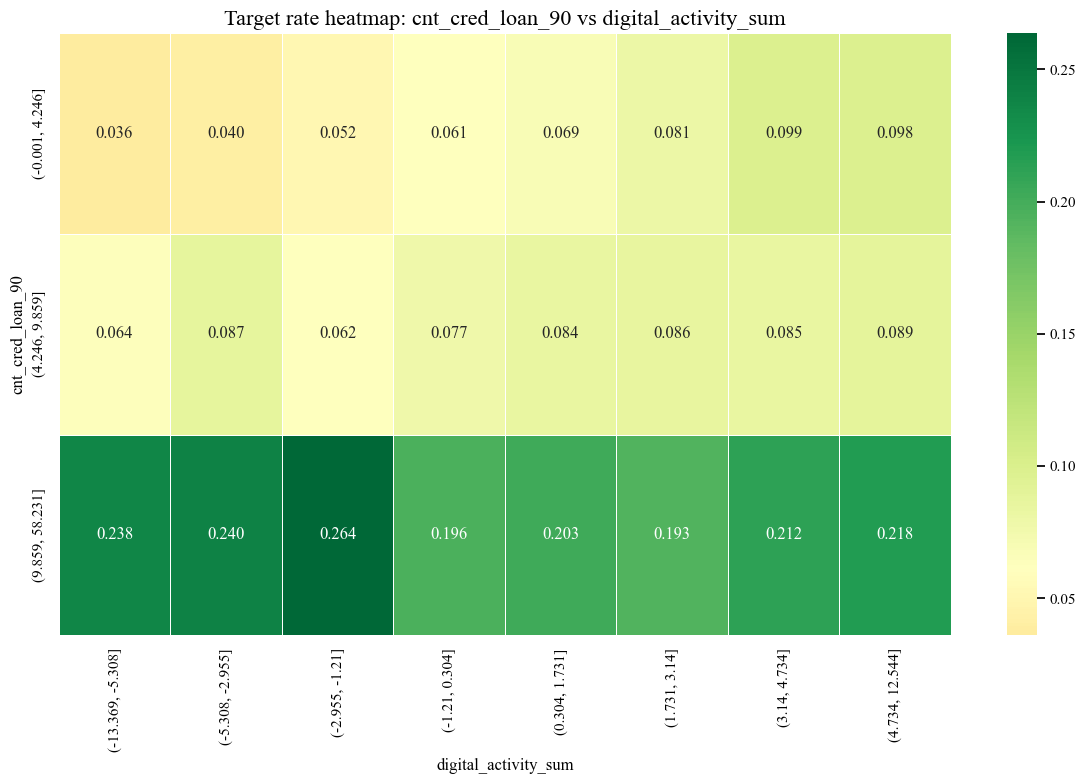

In [6]:
def plot_interaction_heatmap(data, feature_x, feature_y, bins=8):
    tmp = data[[feature_x, feature_y, TARGET_COL]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    tmp["x_bin"] = pd.qcut(tmp[feature_x], q=bins, duplicates="drop")
    tmp["y_bin"] = pd.qcut(tmp[feature_y], q=bins, duplicates="drop")

    pivot = (
        tmp
        .groupby(["y_bin", "x_bin"], observed=True)[TARGET_COL]
        .mean()
        .unstack()
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        pivot,
        cmap="RdYlGn",
        center=train_eda[TARGET_COL].mean(),
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
    )
    plt.title(f"Target rate heatmap: {feature_y} vs {feature_x}", fontsize=16)
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()

interaction_pairs = [
    ("rate_spread", "loan_to_limit_max"),
    ("abs_rate_spread", "loan_to_limit_max"),
    ("overdraft_range", "loan_amount_last"),
    ("sum_deb_ul_ratio_30_90", "cnt_deb_ul_ip_ratio_30_90"),
    ("digital_activity_sum", "cnt_cred_loan_90"),
]

for feature_x, feature_y in interaction_pairs:
    plot_interaction_heatmap(train_eda, feature_x, feature_y, bins=8)

### 7. Анализ категориальных признаков

Признаки `db_group_last` (тип последнего кредитного продукта) и `fl_adminarea` (регион) - сильные предикторы с высоким процентом пропусков (38% и 30% соответственно). Для каждого признака строим:

- **Bar chart** acceptance rate по категориям (с доверительными интервалами через размер выборки).
- **Temporal chart** - изменение acceptance rate по месяцам, чтобы оценить стабильность категории.

Пропуски кодируются отдельной категорией `__MISSING__` - их acceptance rate значимо отличается от непропущенных.

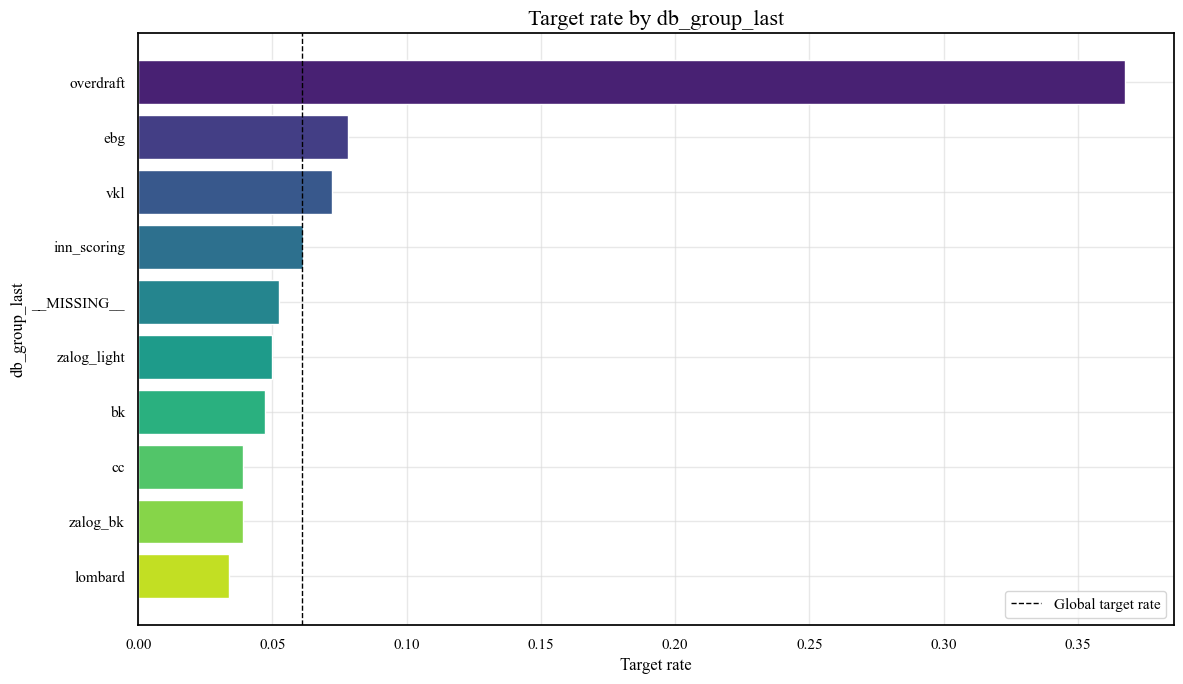

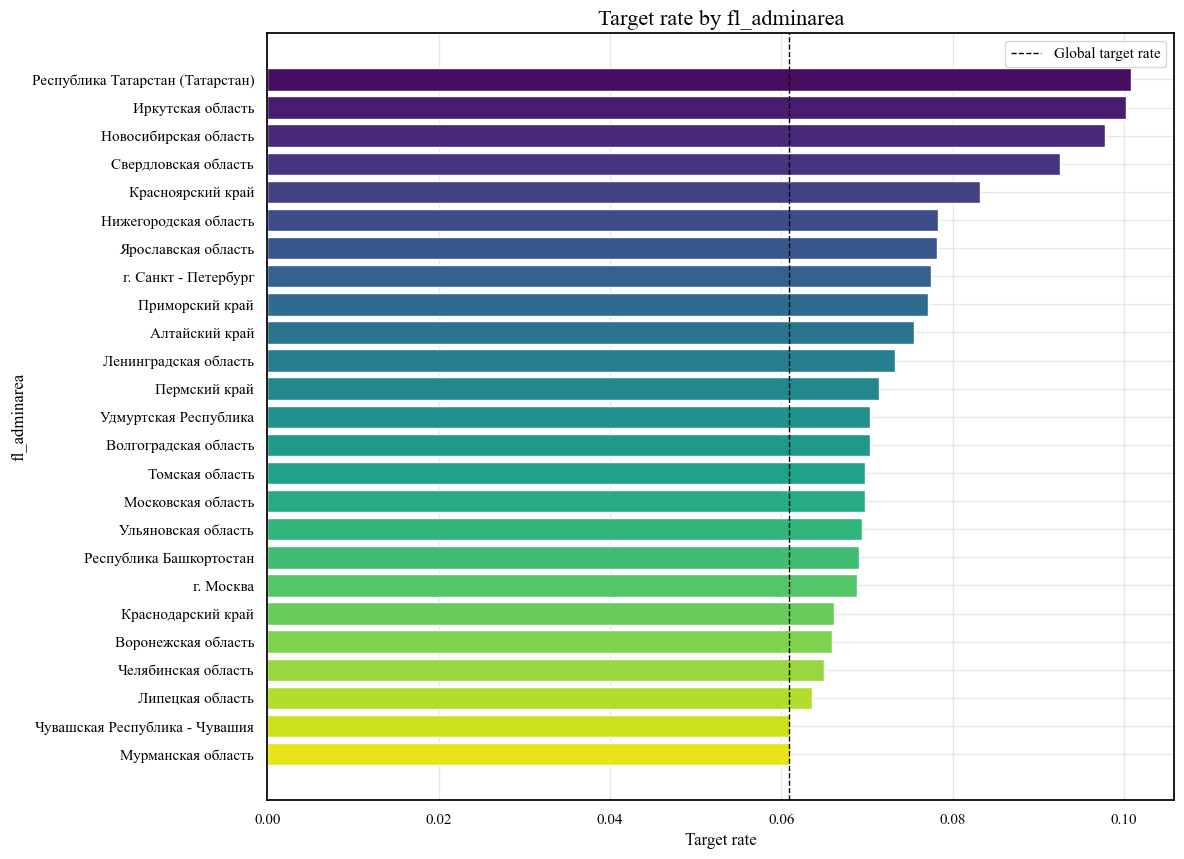

,category,applications,target_rate
6,overdraft,2112,0.367424
3,ebg,3872,0.077996
7,vkl,5370,0.072253
4,inn_scoring,54098,0.061500
0,__MISSING__,55883,0.052485
9,zalog_light,8832,0.049706
1,bk,11833,0.047241
2,cc,1048,0.039122
8,zalog_bk,1337,0.038893
5,lombard,856,0.033879


,category,applications,target_rate
56,Республика Татарстан (Татарстан),3423,0.100789
14,Иркутская область,1267,0.100237
35,Новосибирская область,3998,0.097799
64,Свердловская область,5036,0.092534
24,Красноярский край,1827,0.083196
33,Нижегородская область,1979,0.078322
80,Ярославская область,793,0.078184
82,г. Санкт - Петербург,7306,0.077471
41,Приморский край,921,0.077090
1,Алтайский край,1973,0.075520


In [7]:
def plot_category_target_rate(data, feature, min_count=300, top_n=25):
    stats = (
        data
        .assign(category=data[feature].fillna("__MISSING__").astype(str))
        .groupby("category", observed=True)
        .agg(
            applications=(ID_COL, "count"),
            target_rate=(TARGET_COL, "mean"),
        )
        .reset_index()
    )

    stats = stats[stats["applications"] >= min_count]
    stats = stats.sort_values("target_rate", ascending=False).head(top_n)

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    colors = sns.color_palette("viridis", len(stats))
    plt.barh(stats["category"], stats["target_rate"], color=colors)
    plt.axvline(data[TARGET_COL].mean(), color="black", linestyle="--", linewidth=1, label="Global target rate")
    plt.title(f"Target rate by {feature}", fontsize=16)
    plt.xlabel("Target rate")
    plt.ylabel(feature)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return stats

db_group_stats = plot_category_target_rate(train_eda, "db_group_last", min_count=100, top_n=20)
adminarea_stats = plot_category_target_rate(train_eda, "fl_adminarea", min_count=500, top_n=25)

display(db_group_stats)
display(adminarea_stats)

### 8. Временная динамика acceptance rate по продуктовым сегментам

Для диагностики стабильности признака `db_group_last` анализируем, как acceptance rate изменяется по месяцам внутри каждого сегмента. Нестабильность внутри сегмента во времени снижает предсказательную ценность признака и создаёт риск дрейфа на test.

Ожидаемый паттерн: сегмент `overdraft` стабильно выше среднего, сегменты без кредитной истории - стабильно ниже.

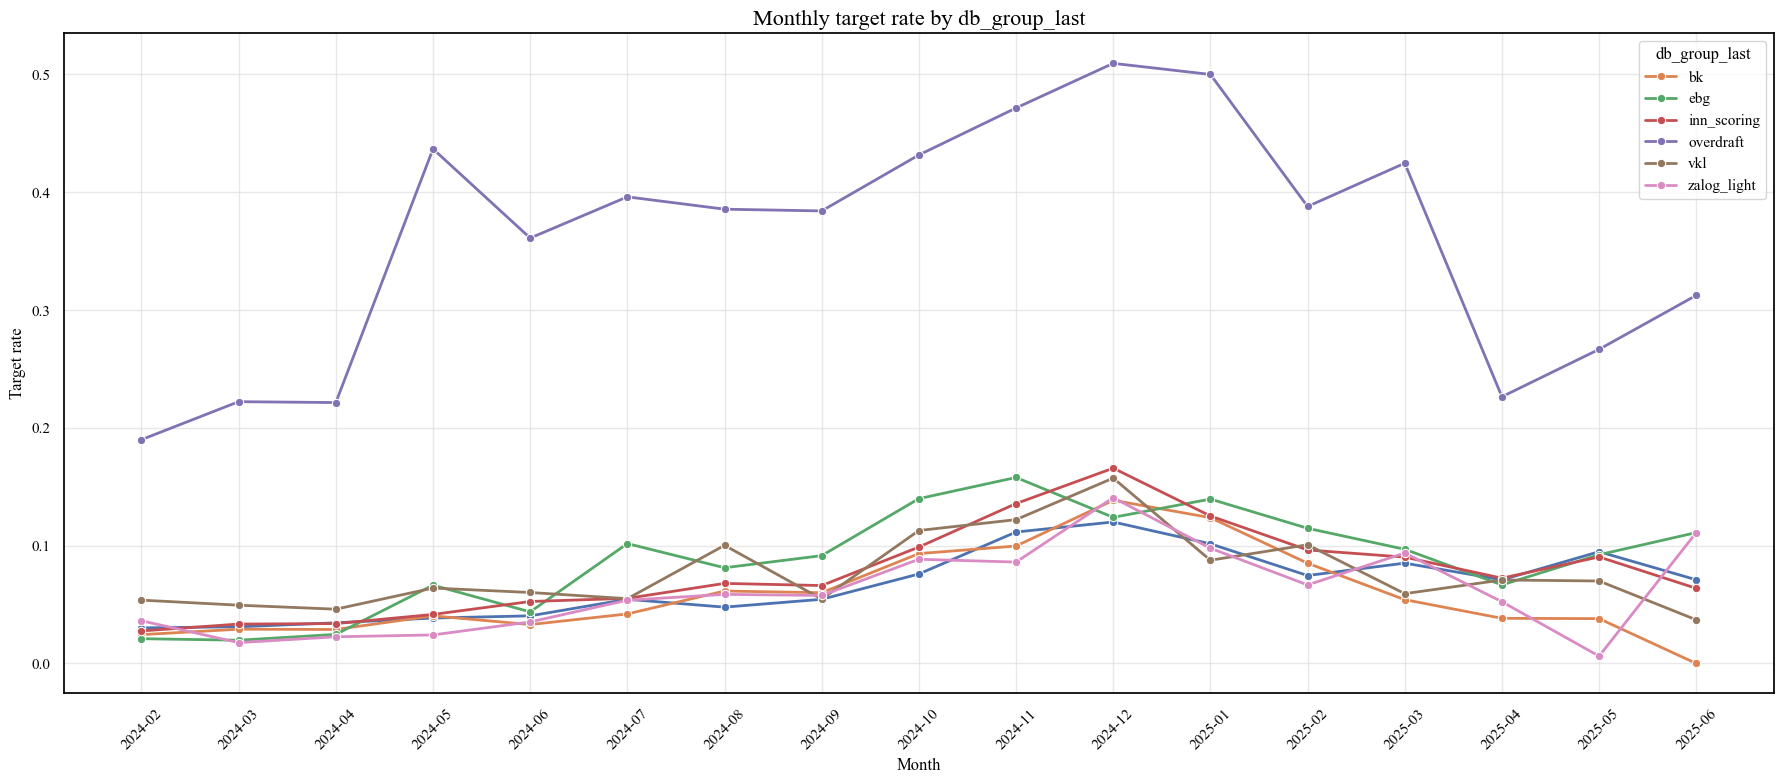

In [8]:
top_groups = (
    train_eda["db_group_last"]
    .fillna("__MISSING__")
    .value_counts()
    .head(7)
    .index
)

monthly_group = (
    train_eda
    .assign(db_group_last=train_eda["db_group_last"].fillna("__MISSING__"))
    .query("db_group_last in @top_groups")
    .groupby(["decision_month", "db_group_last"], observed=True)
    .agg(
        applications=(ID_COL, "count"),
        target_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(18, 8))
sns.lineplot(
    data=monthly_group,
    x="decision_month",
    y="target_rate",
    hue="db_group_last",
    marker="o",
    linewidth=2,
)
plt.title("Monthly target rate by db_group_last", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Target rate")
plt.xticks(rotation=45)
plt.legend(title="db_group_last")
plt.tight_layout()
plt.show()